In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import tifffile
import numpy as np
import matplotlib.pyplot as plt

REGION = "XETG00174__0064842__Region_1__20250514__154857"

warped_he = tifffile.imread(
    f"/data1/peerd/ghoshr/nick_alignment/output-{REGION}/warped_outputs/warped_he.tiff"
)
warped_he

array([[[252, 252, 251],
        [252, 252, 251],
        [252, 252, 251],
        ...,
        [252, 252, 251],
        [252, 252, 251],
        [252, 252, 251]],

       [[252, 252, 251],
        [252, 252, 251],
        [252, 252, 251],
        ...,
        [252, 252, 251],
        [252, 252, 251],
        [252, 252, 251]],

       [[252, 252, 251],
        [252, 252, 251],
        [252, 252, 251],
        ...,
        [252, 252, 251],
        [252, 252, 251],
        [252, 252, 251]],

       ...,

       [[254, 254, 252],
        [254, 254, 252],
        [255, 255, 253],
        ...,
        [252, 252, 251],
        [252, 252, 251],
        [252, 252, 251]],

       [[254, 254, 252],
        [255, 255, 253],
        [255, 255, 253],
        ...,
        [252, 252, 251],
        [252, 252, 251],
        [252, 252, 251]],

       [[254, 254, 252],
        [255, 255, 253],
        [254, 254, 252],
        ...,
        [252, 252, 251],
        [252, 252, 251],
        [252, 252, 251]]

In [ ]:
dapi = tifffile.imread(
    f"/data1/peerd/ghoshr/nick_alignment/output-{REGION}/warped_outputs/dapi_output.tiff"
)

dapi.shape, warped_he.shape

((44291, 51143), (44291, 51143, 3))

In [4]:
import cv2
from skimage.filters import threshold_li

def normalize(img, quantiles=[0.001, 0.99], clip_limit=1.0, grid_size=(20, 20)):
    """Fast normalization using OpenCV CLAHE."""
    lo, hi = np.quantile(img, quantiles)
    img = np.clip(img, lo, hi)
    
    if hi - lo < 1e-6:
        return np.zeros_like(img, dtype=np.float32)
    
    img_norm = ((img - lo) / (hi - lo) * 255).astype(np.uint8)
    
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=grid_size)

    norm = clahe.apply(img_norm).astype(np.float32) / 255.0
    if np.count_nonzero(norm == 0) == 0:
        h, w = norm.shape[:2]
        r0, c0 = max(0, h // 2 - 1000), max(0, w // 2 - 1000)
        r1, c1 = min(h, h // 2 + 1000), min(w, w // 2 + 1000)
        thresh = threshold_li(norm[r0:r1, c0:c1])
        print("Li threshold:", thresh)
        norm = np.where(norm > thresh, norm, 0)
    return norm


def create_rgb_overlay(fixed, moving):
    fixed = fixed.astype(np.float32)
    moving = moving.astype(np.float32)

    # Normalize to [0,1] range
    if fixed.max() > 0:
        fixed /= fixed.max()
    if moving.max() > 0:
        moving /= moving.max()

    # Create RGB without perceptual scaling
    rgb = np.zeros((*fixed.shape, 3), dtype=np.float32)
    rgb[..., 0] = fixed  # R
    rgb[..., 1] = moving  # G
    rgb[..., 2] = moving  # B

    rgb = np.clip(rgb, 0, 1)  # Ensure values are in [0, 1]
    return rgb


In [5]:
import csbdeep
from stardist.models import StarDist2D

def isolate_nuclei_stardist(he_crop, nms_thresh=0.3, prob_thresh=0.6):
    axis_norm = (0, 1, 2)
    he_norm = csbdeep.utils.normalize(he_crop, 1, 99.8, axis=axis_norm)
    model = StarDist2D.from_pretrained("2D_versatile_he")
    
    if he_crop.shape[0] < 4096 and he_crop.shape[1] < 4096:
        labels, _ = model.predict_instances(
            he_norm, nms_thresh=nms_thresh, prob_thresh=prob_thresh
        )
    else:
        labels, _ = model.predict_instances_big(
            he_norm, nms_thresh=nms_thresh, prob_thresh=prob_thresh, axes="YXC", 
            block_size=4096, min_overlap=128, context=128, n_tiles=(4,4,1)
        )
    
    nuclei_mask = (labels > 0).astype(float)
    return nuclei_mask


def get_nuclei(he_img):
    nuclei_mask = isolate_nuclei_stardist(he_img)
    he_gray = cv2.cvtColor(he_img, cv2.COLOR_RGB2GRAY).astype(np.float32)
    he_nuc = np.where(nuclei_mask > 0, he_gray, 0)
    return nuclei_mask, he_nuc

I0000 00:00:1775774807.527495  928272 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775774807.575579  928272 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 AMX_FP16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775774816.356985  928272 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


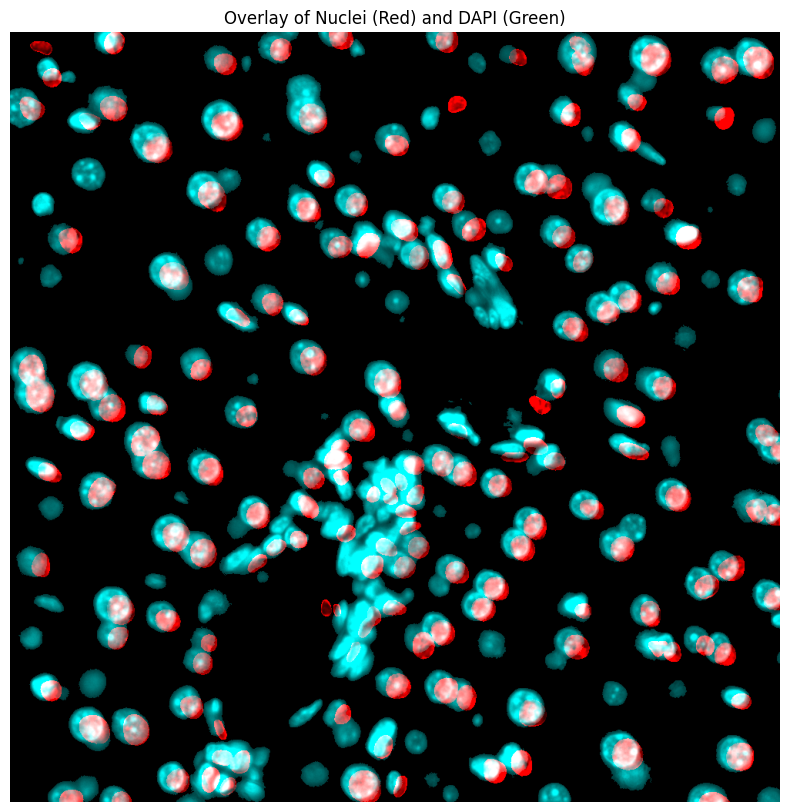

In [ ]:
crop_region = (slice(25000, 26000), slice(25000, 26000))

he_crop = warped_he#[crop_region]
dapi_crop = dapi[crop_region]

nuclei_mask, he_nuc = get_nuclei(he_crop)
he_nuc_norm = normalize(he_nuc)
dapi_norm = normalize(dapi)

overlay = create_rgb_overlay(he_nuc_norm[crop_region], dapi_norm[crop_region])
plt.figure(figsize=(10, 10))
plt.imshow(overlay)
plt.axis("off")
plt.title("Overlay of Nuclei (Red) and DAPI (Green)")
plt.show()

In [10]:
he_nuc_norm.shape, dapi_norm.shape

((44291, 51143), (44291, 51143))

In [13]:
# %% Cell X: Define recommend_mirage_params
from skimage.measure import label, regionprops
from scipy.spatial import cKDTree
from scipy.stats import median_abs_deviation
from segmentation_tools.utils.utils import normalize as normalize_util
import numpy as np

def recommend_mirage_params(fixed_image, moving_image, n_crops=10, crop_size=1000,
                            max_match_distance=100, mad_outlier_factor=3.0, verbose=True):
    """
    Recommend MIRAGE parameters based on centroids of nuclei in fixed and moving images.
    
    fixed_image: 2D numpy array (DAPI)
    moving_image: 2D numpy array (H&E)
    n_crops: number of random sub-crops to estimate displacement
    crop_size: size of sub-crops for centroid detection
    max_match_distance: maximum allowed distance to match centroids
    mad_outlier_factor: factor for outlier removal
    """
    H, W = fixed_image.shape[:2]
    all_fixed_centroids, all_moving_centroids = [], []
    all_fixed_areas, all_moving_areas = [], []

    np.random.seed(42)
    for _ in range(n_crops):
        r = np.random.randint(0, max(1, H - crop_size))
        c = np.random.randint(0, max(1, W - crop_size))
        crop = (slice(r, r + crop_size), slice(c, c + crop_size))
        fixed_crop = fixed_image[crop]
        moving_crop = moving_image[crop]

        def _segment_centroids(img, min_area=50):
            mask = normalize_util(img.astype(np.float32)) > 0
            labeled = label(mask)
            props = regionprops(labeled)
            centroids, areas = [], []
            for p in props:
                if p.area >= min_area:
                    centroids.append(np.array(p.centroid) + np.array([r, c]))
                    areas.append(p.area)
            return centroids, areas

        fc, fa = _segment_centroids(fixed_crop)
        mc, ma = _segment_centroids(moving_crop)
        all_fixed_centroids.extend(fc)
        all_moving_centroids.extend(mc)
        all_fixed_areas.extend(fa)
        all_moving_areas.extend(ma)

    fixed_centroids = np.array(all_fixed_centroids) if all_fixed_centroids else np.zeros((0, 2))
    moving_centroids = np.array(all_moving_centroids) if all_moving_centroids else np.zeros((0, 2))
    fixed_areas = np.array(all_fixed_areas)
    moving_areas = np.array(all_moving_areas)

    n_fixed, n_moving = len(fixed_centroids), len(moving_centroids)
    defaults = {
        "offset": 30, "pad": 30, "smoothness_radius": 50, "pos_encoding_L": 6,
        "dissim_sigma": 30,
    }
    if n_fixed < 3 or n_moving < 3:
        if verbose:
            print(f"WARNING: Too few nuclei (fixed={n_fixed}, moving={n_moving}). Using defaults.")
        return defaults, [], []

    tree = cKDTree(fixed_centroids)
    dists, idx = tree.query(moving_centroids, k=1)
    valid = dists < max_match_distance
    matched_m = moving_centroids[valid]
    matched_f = fixed_centroids[idx[valid]]
    raw_disp = matched_f - matched_m

    if len(raw_disp) < 3:
        if verbose:
            print(f"WARNING: Too few matches ({len(raw_disp)}). Using defaults.")
        return defaults, [], []

    median_disp = np.median(raw_disp, axis=0)
    devs = np.linalg.norm(raw_disp - median_disp, axis=1)
    mad = median_abs_deviation(devs)
    inlier = devs < (np.median(devs) + mad_outlier_factor * mad) if mad >= 1e-6 else np.ones(len(devs), dtype=bool)
    inlier_disp = raw_disp[inlier]
    mags = np.linalg.norm(inlier_disp, axis=1)
    median_mag = np.median(mags)

    # Estimate typical nucleus diameter
    hist, edges = np.histogram(np.concatenate([fixed_areas, moving_areas]), bins=100)
    mode_area = edges[np.argmax(hist)]
    nuc_diam = np.sqrt(mode_area / np.pi) * 2

    # Recommended parameters
    rec_offset = max(int(np.ceil(median_mag * 1.3)), 10)
    rec_pad = max(rec_offset, int(np.ceil(nuc_diam * 0.8)))
    rec_smooth = max(int(np.ceil(nuc_diam * 1.3)), 30)
    disp_std = np.std(mags)
    rec_L = 4 if disp_std < 3 else (6 if disp_std < 10 else 8)
    rec_dissim = max(int(np.ceil(nuc_diam * 0.5)), rec_offset)

    result = {
        "offset": rec_offset,
        "pad": rec_pad,
        "smoothness_radius": rec_smooth,
        "pos_encoding_L": rec_L,
        "dissim_sigma": rec_dissim,
    }

    if verbose:
        print(f"Recommended MIRAGE params: {result}")

    return result

params = recommend_mirage_params(dapi_norm, he_nuc_norm)

Li threshold: 0.118541636
Li threshold: 0.061841678
Li threshold: 0.11644979
Li threshold: 0.06785586
Li threshold: 0.120535724
Li threshold: 0.0807304
Recommended MIRAGE params: {'offset': 15, 'pad': 30, 'smoothness_radius': 49, 'pos_encoding_L': 6, 'dissim_sigma': 19}


In [17]:
import mirage

def create_rgb_overlay(fixed, moving):
    """Create red-cyan overlay: red=moving, cyan=fixed."""
    fixed = fixed.astype(np.float32)
    moving = moving.astype(np.float32)

    if fixed.max() > 0:
        fixed /= fixed.max()
    if moving.max() > 0:
        moving /= moving.max()

    rgb = np.zeros((*fixed.shape, 3), dtype=np.float32)
    rgb[..., 0] = moving  # R
    rgb[..., 1] = fixed   # G
    rgb[..., 2] = fixed   # B

    return np.clip(rgb, 0, 1)

def run_mirage(
    moving_image,
    fixed_image,
    pad=30,
    offset=30,
    smoothness_weight=0.2,
    smoothness_radius=35,           # ~1 nucleus diameter
    pos_encoding_L=6,
    dissim_sigma=25,
    num_neurons=128,
    num_layers=3,
    batch_size=1024,
    num_steps=2048,
    LR=0.012575,
    pool=4,
    bin_mask=None,
    loss_type="SSIM",
):
    """Train MIRAGE model for non-linear alignment."""
    mirage_model = mirage.MIRAGE(
        images=moving_image,
        references=fixed_image,
        pad=pad,
        offset=offset,
        bin_mask=bin_mask,
        num_neurons=num_neurons,
        num_layers=num_layers,
        LR=LR,
        LR_sched=True,
        batch_size=batch_size,
        pool=pool,
        loss_type=loss_type,
        smoothness_weight=smoothness_weight,
        smoothness_radius=smoothness_radius,
        rigidity_weight=0.1,
        pos_encoding_L=pos_encoding_L,
        dissim_sigma=dissim_sigma,
    )

    mirage_model.train(num_steps=num_steps)
    mirage_model.compute_transform()

    aligned_image = mirage_model.apply_transform(moving_image)
    transform = mirage_model.get_transform()
    return aligned_image, transform, mirage_model

aligned_image, transform, mirage_model = run_mirage(
    moving_image=he_nuc_norm,
    fixed_image=dapi_norm,
    pad=params["pad"],
    offset=params["offset"],
    smoothness_radius=params["smoothness_radius"],
    pos_encoding_L=params["pos_encoding_L"],
    dissim_sigma=params["dissim_sigma"]
)


MIRAGE Config:
  num_layers: 3
  num_neurons: 128
  pad: 7
  offset: 3
  batch_size: 1024
  LR: 0.012575
  LR_sched: True
  pool: 4
  smoothness_weight: 0.2
  rigidity_weight: 0.1
  parsimony_weight: 0.01
  dissim_sigma: 19
  dissim_sigma_pooled: 4.75

MIRAGE Config (compact): layers=3, neurons=128, pad=7, offset=3, batch=1024, lr=0.012575, smooth_w=0.2, rigid_w=0.1, pars_w=0.01,dissim_sigma=19, dissim_sigma_pooled=4.75,pool=4
Moving image: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
Reference image: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
Early Stop Patience: 500
Num Steps: 2048


Early stop at step 1121 (best SSIM loss: -0.75825), patience: 500/500:  55%|█████▍    | 1121/2048 [01:00<00:49, 18.65it/s]


Restored best weights from early stopping (SSIM loss: -0.75825). Time taken: 0.00 seconds.


Computing transform: 100%|██████████| 22652/22652 [01:02<00:00, 360.37it/s]


Transform loop: 62.8588s


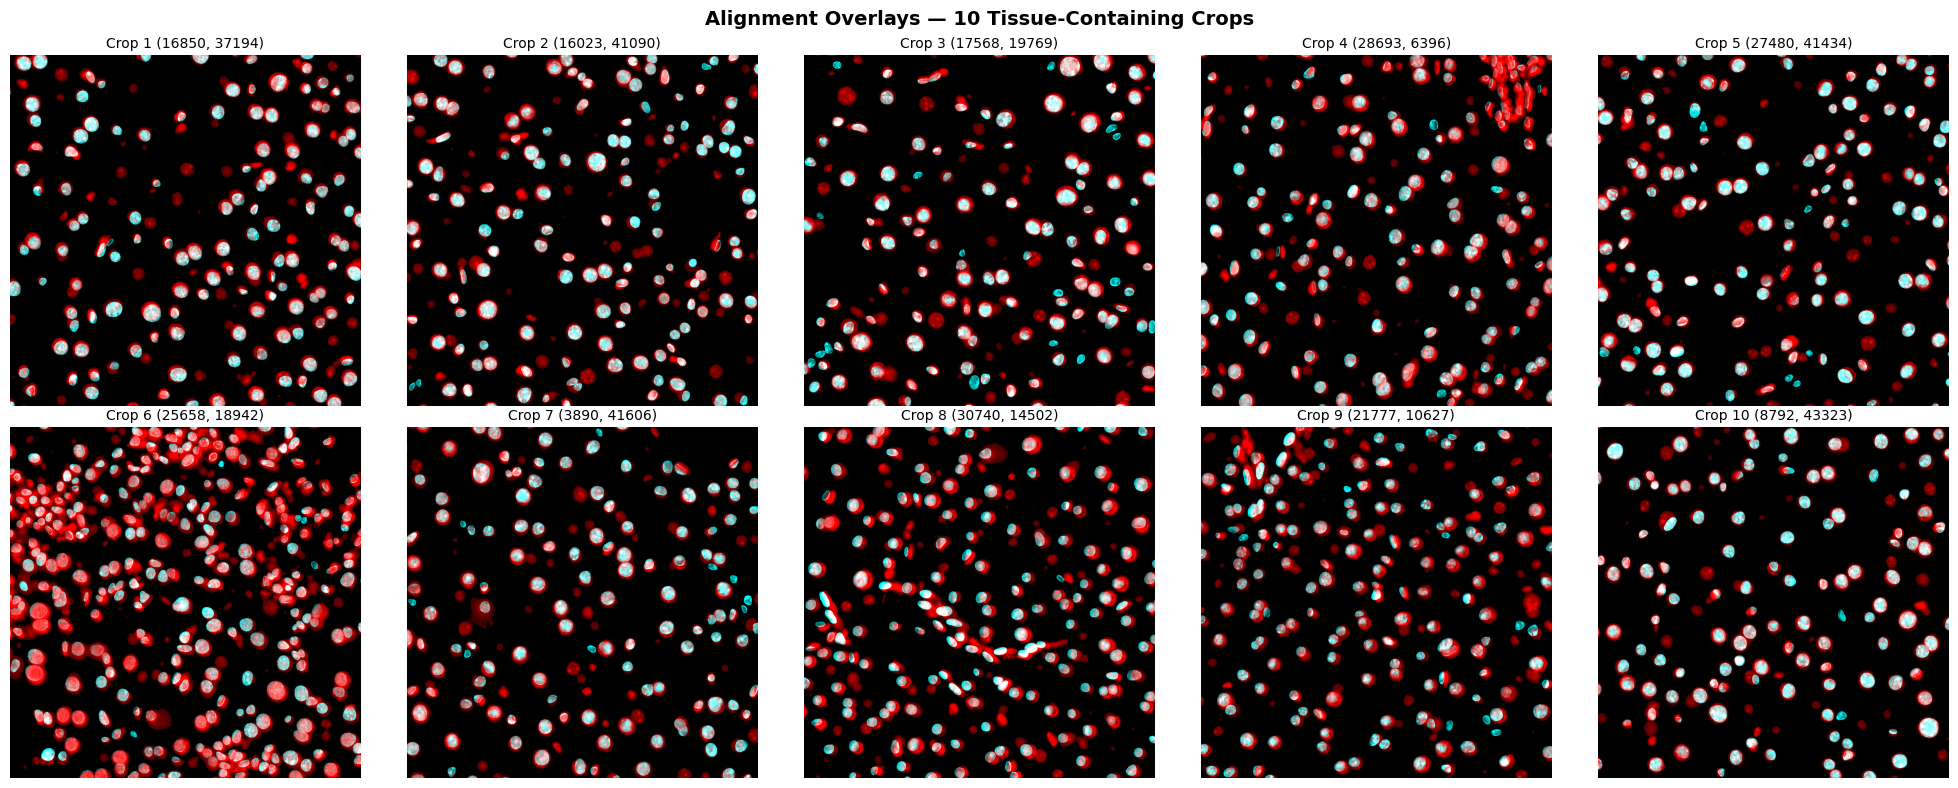

In [ ]:
H, W = dapi_norm.shape[:2]
crop_size = 1000
n_crops = 10
min_mean = 0.05 
min_variance = 0.001

np.random.seed(42)
valid_crops = []

while len(valid_crops) < n_crops:
    r = np.random.randint(0, max(1, H - crop_size))
    c = np.random.randint(0, max(1, W - crop_size))
    crop_region = (slice(r, r + crop_size), slice(c, c + crop_size))
    
    crop_data = dapi_norm[crop_region]
    crop_mean = crop_data.mean()
    crop_var = crop_data.var()
    
    if crop_mean > min_mean and crop_var > min_variance:
        valid_crops.append((r, c, crop_region))

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for idx, (r, c, crop_region) in enumerate(valid_crops):
    overlay = create_rgb_overlay(aligned_image[crop_region], dapi_norm[crop_region])
    axes[idx].imshow(overlay)
    axes[idx].axis("off")
    axes[idx].set_title(f"Crop {idx+1} ({r}, {c})", fontsize=10)

fig.suptitle("Alignment Overlays — 10 Tissue-Containing Crops", fontsize=14, fontweight='bold')
plt.tight_layout()
output_fp = f"/data1/peerd/ghoshr/nick_alignment/output-{REGION}/mirage_alignment_crops.png"
plt.savefig(output_fp, dpi=300)
plt.show()

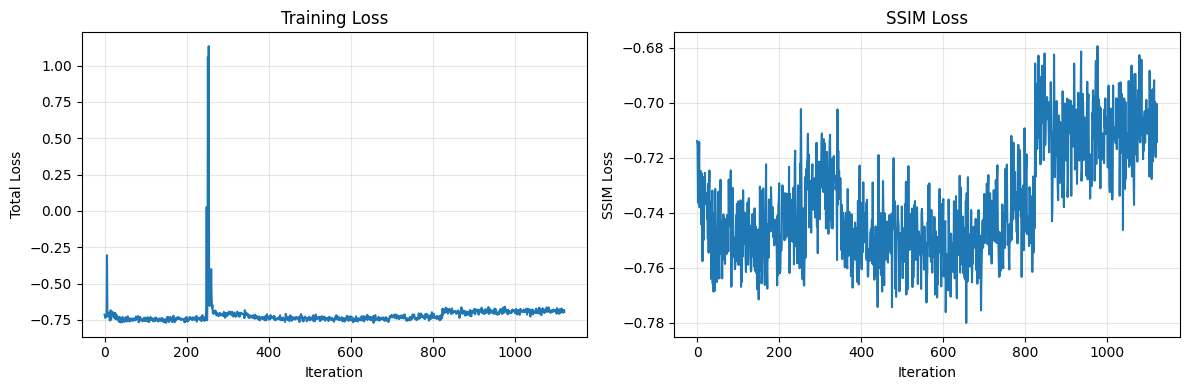

In [21]:
# %% Cell 8: Loss curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))
ax1.plot(mirage_model.loss_history)
ax1.set_title("Training Loss")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Total Loss")
ax1.grid(True, alpha=0.3)

ax2.plot(mirage_model.ssim_history)
ax2.set_title("SSIM Loss")
ax2.set_xlabel("Iteration")
ax2.set_ylabel("SSIM Loss")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

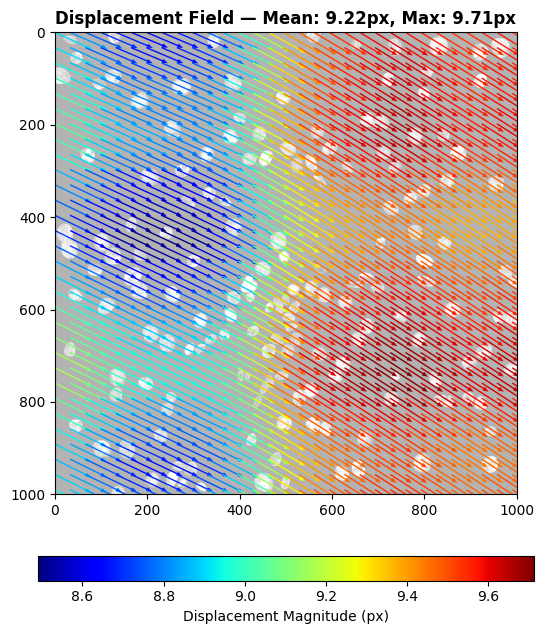

In [ ]:
# %% Cell 9: Displacement / quiver plot
rows_t, cols_t = mirage_model.get_transform().shape[:2]
transform = mirage_model.get_transform()

row_coords, col_coords = np.meshgrid(np.arange(rows_t), np.arange(cols_t), indexing="ij")
displacement = np.zeros_like(transform)
displacement[..., 0] = transform[..., 0] - row_coords
displacement[..., 1] = transform[..., 1] - col_coords

step = max(1, min(rows_t, cols_t) // 30)
Y, X = np.meshgrid(np.arange(0, rows_t, step), np.arange(0, cols_t, step), indexing="ij")
U = displacement[::step, ::step, 1]
V = displacement[::step, ::step, 0]
magnitude = np.sqrt(U ** 2 + V ** 2)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(aligned_image, alpha=0.3, cmap="gray")
q = ax.quiver(
    X, Y, U * 10, V * 10, magnitude,
    angles="xy", scale_units="xy", scale=1,
    cmap="jet", width=0.003, headwidth=3, headlength=4
)
ax.set_xlim(0, cols_t)
ax.set_ylim(rows_t, 0)
ax.set_aspect("equal")
plt.colorbar(q, ax=ax, orientation="horizontal", pad=0.1, shrink=0.8).set_label("Displacement Magnitude (px)")
ax.set_title(f"Displacement Field — Mean: {magnitude.mean():.2f}px, Max: {magnitude.max():.2f}px", fontweight="bold")
plt.show()

Metric                             Before      After      Delta
--------------------------------------------------------------
Mutual Information                 0.1146     0.2215    +0.1069
Gradient Correlation               0.1834     0.3007    +0.1173
Dice (nucleus overlap)             0.5323     0.6337    +0.1014
TRE mean (px)                       21.03      17.53      -3.49
SSIM                               0.6592     0.6910    +0.0318


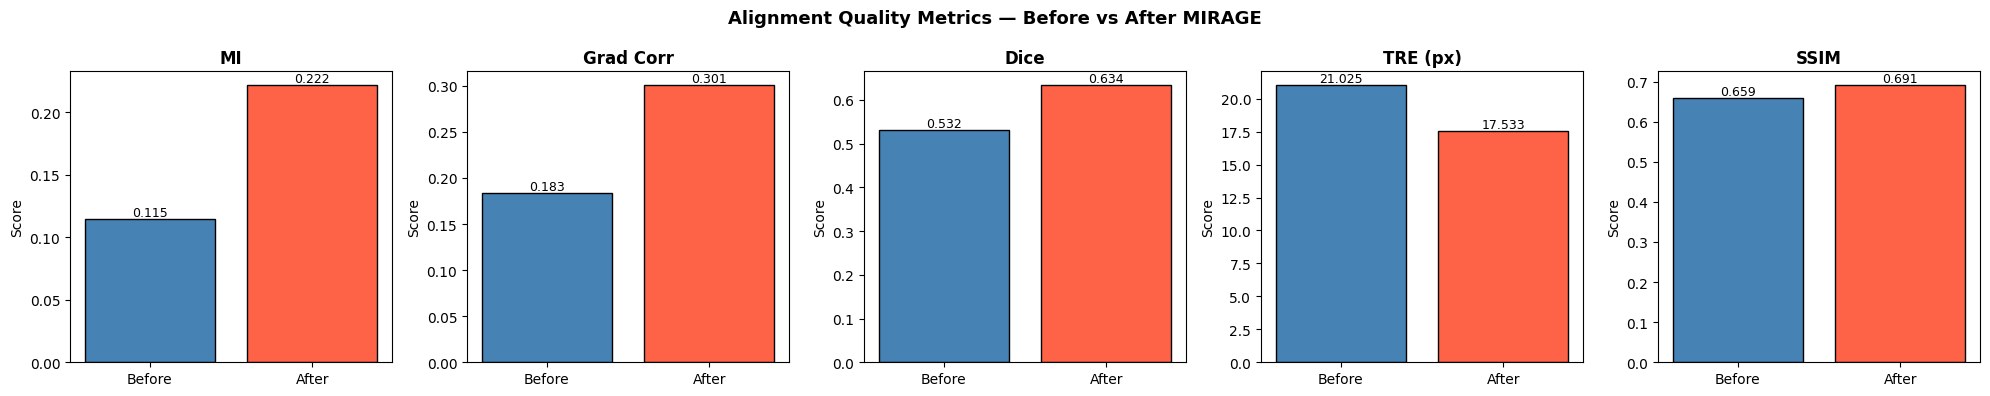

In [ ]:
# %% Alignment quality metrics (EDT)
from scipy.spatial import cKDTree
from sklearn.metrics import mutual_info_score
from skimage.filters import sobel, threshold_li
from skimage.metrics import structural_similarity as ssim_metric
from skimage.measure import label, regionprops
import numpy as np
import matplotlib.pyplot as plt

def match_centroids_for_tre(src, dst, max_dist=100):
    if len(src) == 0 or len(dst) == 0:
        return np.array([]), np.array([]), np.array([])
    tree = cKDTree(dst)
    dists, idx = tree.query(src, k=1)
    valid = dists < max_dist
    return dists[valid], src[valid], dst[idx[valid]]

def gradient_correlation(a, b):
    ga, gb = sobel(a), sobel(b)
    return float(np.corrcoef(ga.ravel(), gb.ravel())[0, 1])

def mutual_information(a, b, bins=64):
    a_flat = (np.clip(a, 0, 1) * (bins - 1)).astype(int).ravel()
    b_flat = (np.clip(b, 0, 1) * (bins - 1)).astype(int).ravel()
    return mutual_info_score(a_flat, b_flat)

def dice(mask_a, mask_b):
    inter = (mask_a & mask_b).sum()
    return 2 * inter / (mask_a.sum() + mask_b.sum() + 1e-8)

def compute_ssim(a, b):
    return float(ssim_metric(a, b, data_range=1.0))

def norm01(x):
    mn, mx = x.min(), x.max()
    return (x - mn) / (mx - mn + 1e-8)

dapi_c      = dapi_norm[crop_region]
he_before_c = he_nuc_norm[crop_region]
he_after_c  = aligned_image[crop_region]    

dapi_n      = norm01(dapi_c)
he_before_n = norm01(he_before_c)
he_after_n  = norm01(he_after_c)

# Fast masking: just threshold, no CLAHE
dapi_mask   = dapi_c > threshold_li(dapi_c)
he_mask_b   = he_before_c > threshold_li(he_before_c)
he_mask_a   = he_after_c  > threshold_li(he_after_c)

def get_centroids(mask, min_area=30):
    props = regionprops(label(mask))
    return np.array([p.centroid for p in props if p.area >= min_area]) if props else np.empty((0,2))

c_dapi   = get_centroids(dapi_mask)
c_he_b   = get_centroids(he_mask_b)
c_he_a   = get_centroids(he_mask_a)

dists_b, _, _ = match_centroids_for_tre(c_he_b, c_dapi)
dists_a, _, _ = match_centroids_for_tre(c_he_a, c_dapi)

# Metrics
mi_before = mutual_information(dapi_n, he_before_n)
mi_after  = mutual_information(dapi_n, he_after_n)
gc_before = gradient_correlation(dapi_n, he_before_n)
gc_after  = gradient_correlation(dapi_n, he_after_n)
dice_before = dice(dapi_mask, he_mask_b)
dice_after  = dice(dapi_mask, he_mask_a)
tre_before = dists_b.mean() if len(dists_b) > 0 else float('nan')
tre_after  = dists_a.mean() if len(dists_a) > 0 else float('nan')
ssim_before = compute_ssim(dapi_n, he_before_n)
ssim_after  = compute_ssim(dapi_n, he_after_n)

# Print
print(f"{'Metric':<30} {'Before':>10} {'After':>10} {'Delta':>10}")
print("-" * 62)
print(f"{'Mutual Information':<30} {mi_before:>10.4f} {mi_after:>10.4f} {mi_after-mi_before:>+10.4f}")
print(f"{'Gradient Correlation':<30} {gc_before:>10.4f} {gc_after:>10.4f} {gc_after-gc_before:>+10.4f}")
print(f"{'Dice (nucleus overlap)':<30} {dice_before:>10.4f} {dice_after:>10.4f} {dice_after-dice_before:>+10.4f}")
print(f"{'TRE mean (px)':<30} {tre_before:>10.2f} {tre_after:>10.2f} {tre_after-tre_before:>+10.2f}")
print(f"{'SSIM':<30} {ssim_before:>10.4f} {ssim_after:>10.4f} {ssim_after-ssim_before:>+10.4f}")

# Bar chart
metrics     = ['MI', 'Grad Corr', 'Dice', 'TRE (px)', 'SSIM']
before_vals = [mi_before, gc_before, dice_before, tre_before, ssim_before]
after_vals  = [mi_after,  gc_after,  dice_after,  tre_after,  ssim_after]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, name, bv, av in zip(axes, metrics, before_vals, after_vals):
    bars = ax.bar(['Before', 'After'], [bv, av], color=['steelblue', 'tomato'], edgecolor='black')
    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('Score')
    for bar, v in zip(bars, [bv, av]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)

fig.suptitle('Alignment Quality Metrics — Before vs After MIRAGE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()